## **Vanilla ChatBot Using `LangGraph`**

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
from dotenv import load_dotenv
load_dotenv()
import os

llm = ChatOpenAI()

## **Chat node define**

In [5]:
def chat_node(state: ChatState):
    # user messages
    messages = state["messages"]

    response = llm.invoke(messages)

    return {
        "messages": [response.content]
    }

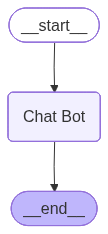

In [7]:
graph = StateGraph(ChatState)

graph.add_node("Chat Bot",chat_node)

graph.add_edge(START, "Chat Bot")

chat_bot = graph.compile(checkpointer=InMemorySaver())

chat_bot

## **Inference chatbot**

In [8]:
config = {
    "configurable": {
        "thread_id": "chat_1"
    }
}

In [9]:
response = chat_bot.invoke(
    {
        "messages": [HumanMessage(content="Hello, I'm Al Amin")]
    },
    config=config
)

response

{'messages': [HumanMessage(content="Hello, I'm Al Amin", additional_kwargs={}, response_metadata={}, id='e241daf9-2547-44be-8f39-d0bc8fcdb608'),
  HumanMessage(content='Nice to meet you, Al Amin! How can I assist you today?', additional_kwargs={}, response_metadata={}, id='6e0e7b1b-553f-4c3d-ace3-3855a1b55520')]}

In [10]:
response = chat_bot.invoke(
    {
        "messages": [HumanMessage(content="Can you tell my name and what is the mining of my name?")]
    },
    config=config
)

response["messages"][-1].content

'Your name, Al Amin, is of Arabic origin and it means "the trustworthy" or "the faithful" in Arabic. It is a common name given to boys in Muslim-majority countries and is often associated with qualities of honesty, integrity, and reliability.'

## **Build and Interactive Chat System**

In [11]:
thread_id = "chat_2"
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

while True:
    user_message = input("Type Hare: ")
    print("User", user_message)

    if user_message.strip().lower() in ["exit", "bye", "quit"]:
        break

    response = chat_bot.invoke(
        {
            "messages": [HumanMessage(content=user_message)]
        },
        config=config
    )

    print("AI: ", response["messages"][-1].content)

User Hi, i'm al amin
AI:  Hello Al Amin, nice to meet you. How can I assist you today?
User can you tell me how you train
AI:  Of course! I am an AI language model trained by OpenAI, specifically the GPT-3 model. My training involved being fed a large dataset of text from the internet, books, articles, and other sources, in order to learn the patterns and structures of human language. This training process allows me to generate text that is coherent, contextually relevant, and can engage in meaningful conversations with users like yourself. Is there anything specific you would like to know about my training process?
User what is my name i told you
AI:  You mentioned that your name is Al Amin. How can I assist you today, Al Amin?
User how you remmber my name?
AI:  I do not have the ability to remember details about individual users or carry on a persistent conversation across different sessions. Each interaction with me is independent, and I do not have the capability to retain personal

In [12]:
chat_bot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content="Hi, i'm al amin", additional_kwargs={}, response_metadata={}, id='43aaff91-c894-455d-a8b5-214008b79bb3'), HumanMessage(content='Hello Al Amin, nice to meet you. How can I assist you today?', additional_kwargs={}, response_metadata={}, id='1be260c5-8240-49e2-9c17-e16cf30cd046'), HumanMessage(content='can you tell me how you train', additional_kwargs={}, response_metadata={}, id='9a5a5d46-7662-4dbb-af0a-4264cccf9cc8'), HumanMessage(content='Of course! I am an AI language model trained by OpenAI, specifically the GPT-3 model. My training involved being fed a large dataset of text from the internet, books, articles, and other sources, in order to learn the patterns and structures of human language. This training process allows me to generate text that is coherent, contextually relevant, and can engage in meaningful conversations with users like yourself. Is there anything specific you would like to know about my training process?', a